## **Проект модуля. Нейросеть для классификации таблеток**


##### **Проект «Классификатор таблеток»**
**Бизнес-контекст.** На небольших фармацевтических предприятиях таблетки обычно фасуются по банкам вручную. Последние годы вводятся маленькие автоматические линии для фасовки — они механически расфасовывают таблетки из большой ёмкости по маленьким. 



**Проблема.** Процесс фасовки автоматизирован не полностью, специалист должен перепроверять каждую упаковку таблеток. Если в партию случайно попадёт не та таблетка, это может нанести вред здоровью пациента.

**Бизнес-задача.** Добавить автоматический контроль качества через компьютерное зрение. Для этого нужно разработать алгоритм распознавания таблеток по фото. Это прототип, поэтому достаточно достичь качества распознавания в 75%.


**Формальная задача.** Решить задачу классификации, используя CNN. Входные данные — фото таблетки, требуемый результат — название таблетки (из заданного списка).

### Ход работы

#### Этап 1. Загрузка и предобработка данных

Импорт необходимых библиотек:

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomVerticalFlip, RandomRotation, RandomPhotometricDistort
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Dataset, DataLoader
import torch.optim as optim
import pandas as pd
import torch

Проверка доступности cuda:

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


Загрузка датасета:

In [3]:
ROOT_PATH = 'ogyeiv2'

test_dataset = ImageFolder(ROOT_PATH + "/test")

dataset = ImageFolder(ROOT_PATH + "/train")

train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])

print(f"Количество классов: {len(dataset.classes)}")

print(f"Размер обучающей выборки: {len(train_dataset)}")

print(f"Размер валидационной выборки: {len(val_dataset)}")

print(f"Размер тестовой выборки: {len(test_dataset)}")



Количество классов: 84
Размер обучающей выборки: 1882
Размер валидационной выборки: 470
Размер тестовой выборки: 504


In [ ]:
def get_class_counts(ds, full_dataset=None):

    if full_dataset is not None:  # Subset
        targets = [full_dataset.targets[i] for i in ds.indices]
        classes = full_dataset.classes
    else:  
        targets = ds.targets
        classes = ds.classes

    counts = Counter(targets)
    df = pd.DataFrame({
        "class": [classes[i] for i in counts.keys()],
        "count": counts.values()
    }).sort_values(by="count", ascending=False)
    return df

df_train_counts = get_class_counts(train_dataset, dataset)
df_val_counts = get_class_counts(val_dataset, dataset)
df_test_counts = get_class_counts(test_dataset)

print("\nРаспределение по классам в обучающем датасете:")
print(df_train_counts)

print("\nРаспределение по классам в валидационном датасете:")
print(df_val_counts)

print("\nРаспределение по классам в тестовом датасете:")
print(df_test_counts)




Распределение по классам в обучающем датасете:
                         class  count
0       merckformin_xr_1000_mg     26
24              valeriana_teva     26
34         cataflam_dolo_25_mg     26
70                    milgamma     26
71                    meridian     25
..                         ...    ...
16                     cold_fx     19
31              dulsevia_60_mg     19
66        koleszterin_kontroll     19
21  favipiravir_meditop_200_mg     19
41            strepfen_8_75_mg     16

[84 rows x 2 columns]

Распределение по классам в валидационном датасете:
                         class  count
69            strepfen_8_75_mg     12
1   favipiravir_meditop_200_mg      9
31        koleszterin_kontroll      9
5                      cold_fx      9
8               dulsevia_60_mg      9
..                         ...    ...
4                  lactiv_plus      3
75              valeriana_teva      2
76         cataflam_dolo_25_mg      2
80      merckformin_xr_1000_mg      2
83 

In [5]:
print(f"Полный список названия классов: {dataset.classes}")

Полный список названия классов: ['acc_long_600_mg', 'advil_ultra_forte', 'akineton_2_mg', 'algoflex_forte_dolo_400_mg', 'algoflex_rapid_400_mg', 'algopyrin_500_mg', 'ambroxol_egis_30_mg', 'apranax_550_mg', 'aspirin_ultra_500_mg', 'atoris_20_mg', 'atorvastatin_teva_20_mg', 'betaloc_50_mg', 'bila_git', 'c_vitamin_teva_500_mg', 'calci_kid', 'cataflam_50_mg', 'cataflam_dolo_25_mg', 'cetirizin_10_mg', 'cold_fx', 'coldrex', 'concor_10_mg', 'concor_5_mg', 'condrosulf_800_mg', 'controloc_20_mg', 'covercard_plus_10_mg_2_5_mg_5_mg', 'coverex_4_mg', 'diclopram_75-mg_20-mg', 'dorithricin_mentol', 'dulsevia_60_mg', 'enterol_250_mg', 'favipiravir_meditop_200_mg', 'ibumax_400_mg', 'jutavit_c_vitamin', 'jutavit_cink', 'kalcium_magnezium_cink', 'kalium_r', 'koleszterin_kontroll', 'lactamed', 'lactiv_plus', 'laresin_10_mg', 'letrox_50_mikrogramm', 'lordestin_5_mg', 'merckformin_xr_1000_mg', 'meridian', 'metothyrin_10_mg', 'mezym_forte_10_000_egyseg', 'milgamma', 'milurit_300_mg', 'naprosyn_250_mg', 'nar

Визуализация датасета до трансформаций:

bila_git
olicard_60_mg
concor_5_mg
controloc_20_mg
zadex_60_mg
urzinol
aspirin_ultra_500_mg
tritace_hct_5_mg_25_mg
urzinol
voltaren_dolo_rapid_25_mg


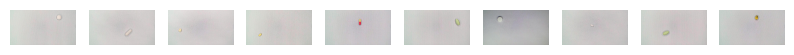

In [6]:
fig = plt.figure(figsize=(10,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')

Необходимые трансформации для датасетов:

In [7]:
train_transform = Compose([
    Resize((384, 384)),
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5], fill=255.0),
    RandomPhotometricDistort(
        brightness=(0.9, 1.1),
        contrast=(0.8, 1.2),
        saturation=(0.8, 1.2),
        hue=(-0.05, 0.05),
        p=0.5
    ),
    ToTensor(),
    Normalize(mean=(0.5,), std=(0.5,)),
])

val_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(mean=(0.5,), std=(0.5,)),
])

Класс-обертка для применения трансформаций к датасетам:

In [8]:
class TransformDataset(Dataset):
  def __init__(self, dataset, transforms):
    super(TransformDataset, self).__init__()
    self.dataset = dataset
    self.transforms = transforms

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    x, y = self.dataset[idx]
    return self.transforms(x), y

Создание DataLoader'ов:

In [9]:
train_dataset, val_dataset = TransformDataset(train_dataset, train_transform), TransformDataset(val_dataset, val_transform)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Этап 2. Объявление модели

В качестве модели для классификации была выбрана resnet50, предобученная на датасете ImageNet

In [10]:
from torchvision.models import resnet50,  ResNet50_Weights
from torchsummary import summary


device = "cuda" if torch.cuda.is_available() else "cpu"


model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)


model = model.to(device)



Вывод архитектуры модели:

In [11]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
from torch import nn

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True    
    

num_classes = 84

model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, num_classes)
)
model.to(device=device)

summary(model, input_size=(3, 384, 384), device=device)  


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 192, 192]           9,408
       BatchNorm2d-2         [-1, 64, 192, 192]             128
              ReLU-3         [-1, 64, 192, 192]               0
         MaxPool2d-4           [-1, 64, 96, 96]               0
            Conv2d-5           [-1, 64, 96, 96]           4,096
       BatchNorm2d-6           [-1, 64, 96, 96]             128
              ReLU-7           [-1, 64, 96, 96]               0
            Conv2d-8           [-1, 64, 96, 96]          36,864
       BatchNorm2d-9           [-1, 64, 96, 96]             128
             ReLU-10           [-1, 64, 96, 96]               0
           Conv2d-11          [-1, 256, 96, 96]          16,384
      BatchNorm2d-12          [-1, 256, 96, 96]             512
           Conv2d-13          [-1, 256, 96, 96]          16,384
      BatchNorm2d-14          [-1, 256,

Я заменила последний слой на кастомный слой с Dropout, чтобы классификатор мог работать с 84 классами и меньше переобучался. Последний сверточный блок (layer4) был разблокирован для обучения, чтобы адаптировать высокоуровневые признаки под особенности таблеток и повысить точность предсказаний.

Обучение модели:

In [ ]:
import torch.optim as optim
from tqdm import tqdm
model_path = "models"
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 15
best_vloss = 1e5

# Код обучения из прошлого урока
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    for batch_index, data in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Эпоха {epoch_index} (train)"):
        inputs, labels = data
        # Извлечение батча
        inputs, labels = inputs.to(device), labels.to(device)
        # Обнуление градиентов
        optimizer.zero_grad()
        # Прямое распространение
        outputs = model(inputs)
        # Подсчёт ошибки
        loss = criterion(outputs, labels)
        # Обратное распространение
        loss.backward()
        # Обновление весов
        optimizer.step()

        # Суммирование ошибки за последние 20 батчей
        running_loss += loss.item()
        if batch_index % 20 == 19:
            last_loss = running_loss / 20. # средняя ошибка за 20 батчей
            print(f'Эпоха: {epoch_index}, батч: {batch_index}, ошибка {last_loss}')
            running_loss = 0.

    return last_loss

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    # Перевод модели в режим обучения
    model.train(True)
    # Эпоха обучения
    avg_loss = train_one_epoch(epoch)

    # Перевод модели в режим валидации
    model.eval()
    running_vloss = 0.0

    with torch.no_grad():
        for i, data in tqdm(enumerate(val_loader), total=len(val_loader), desc=f"Эпоха {epoch} (val)"):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outs = model(inputs)

            vloss = criterion(outs, labels)
            running_vloss += vloss
            avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'meds_classifier_{epoch}.pt'
        torch.save(model.state_dict(), model_path)

    
    # ВАШ КОД ДЛЯ СОХРАНЕНИЯ ЛУЧШЕЙ МОДЕЛИ

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

Эпоха 0


Эпоха 0 (train):  34%|███▍      | 20/59 [00:44<01:35,  2.46s/it]

Эпоха: 0, батч: 19, ошибка 4.433391213417053


Эпоха 0 (train):  68%|██████▊   | 40/59 [01:31<00:44,  2.32s/it]

Эпоха: 0, батч: 39, ошибка 4.2688991785049435


...

Эпоха: 14, батч: 19, ошибка 0.23452980350703


Эпоха 14 (train):  68%|██████▊   | 40/59 [01:09<00:33,  1.75s/it]

Эпоха: 14, батч: 39, ошибка 0.2037717891857028


Эпоха 14 (val): 100%|██████████| 15/15 [00:20<00:00,  1.35s/it]


В конце эпохи ошибка train 0.2037717891857028, ошибка val 0.082448810338974


### Этап 4. Оценка качества

Создание тестового датасета и dataloader'а для него:

In [18]:
test_dataset = TransformDataset(test_dataset, val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Вывод метрик:

In [25]:
from sklearn.metrics import classification_report
labels_predicted = []
labels_true = []

model.eval().to('cpu')

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images, labels = images.to('cpu'), labels.to('cpu')

        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.numpy())
        labels_true.extend(labels.numpy())

report = classification_report(labels_true, labels_predicted, target_names=dataset.classes, output_dict=True)
print(classification_report(labels_true, labels_predicted, target_names=dataset.classes))

                                  precision    recall  f1-score   support

                 acc_long_600_mg       1.00      1.00      1.00         6
               advil_ultra_forte       1.00      1.00      1.00         6
                   akineton_2_mg       1.00      1.00      1.00         6
      algoflex_forte_dolo_400_mg       1.00      1.00      1.00         6
           algoflex_rapid_400_mg       1.00      1.00      1.00         6
                algopyrin_500_mg       1.00      1.00      1.00         6
             ambroxol_egis_30_mg       1.00      1.00      1.00         6
                  apranax_550_mg       1.00      1.00      1.00         6
            aspirin_ultra_500_mg       1.00      1.00      1.00         6
                    atoris_20_mg       1.00      1.00      1.00         6
         atorvastatin_teva_20_mg       1.00      1.00      1.00         6
                   betaloc_50_mg       1.00      1.00      1.00         6
                        bila_git     

*Мы получили accuracy - **97%***

In [26]:
df = pd.DataFrame(report).transpose()

df



,precision,recall,f1-score,support
acc_long_600_mg,1.000000,1.000000,1.000000,6.000000
advil_ultra_forte,1.000000,1.000000,1.000000,6.000000
akineton_2_mg,1.000000,1.000000,1.000000,6.000000
algoflex_forte_dolo_400_mg,1.000000,1.000000,1.000000,6.000000
algoflex_rapid_400_mg,1.000000,1.000000,1.000000,6.000000
...,...,...,...,...
xeter_20_mg,1.000000,1.000000,1.000000,6.000000
zadex_60_mg,1.000000,1.000000,1.000000,6.000000
accuracy,0.972222,0.972222,0.972222,0.972222
macro avg,0.978628,0.972222,0.971196,504.000000


### **Выводы и ответы на вопросы**

### **Топ-5 классов, на которых модель ошибается чаще всего:**

In [27]:
df.sort_values("f1-score").head(5)

,precision,recall,f1-score,support
ocutein,1.000000,0.500000,0.666667,6.0
kalium_r,1.000000,0.500000,0.666667,6.0
novo_c_plus,0.800000,0.666667,0.727273,6.0
kalcium_magnezium_cink,0.666667,1.000000,0.800000,6.0
coverex_4_mg,1.000000,0.666667,0.800000,6.0


### **Почему модель может ошибаться на этих классах?**

Давайте взглянем на изображения таблеток, классы которых модель предсказывает хуже всего:

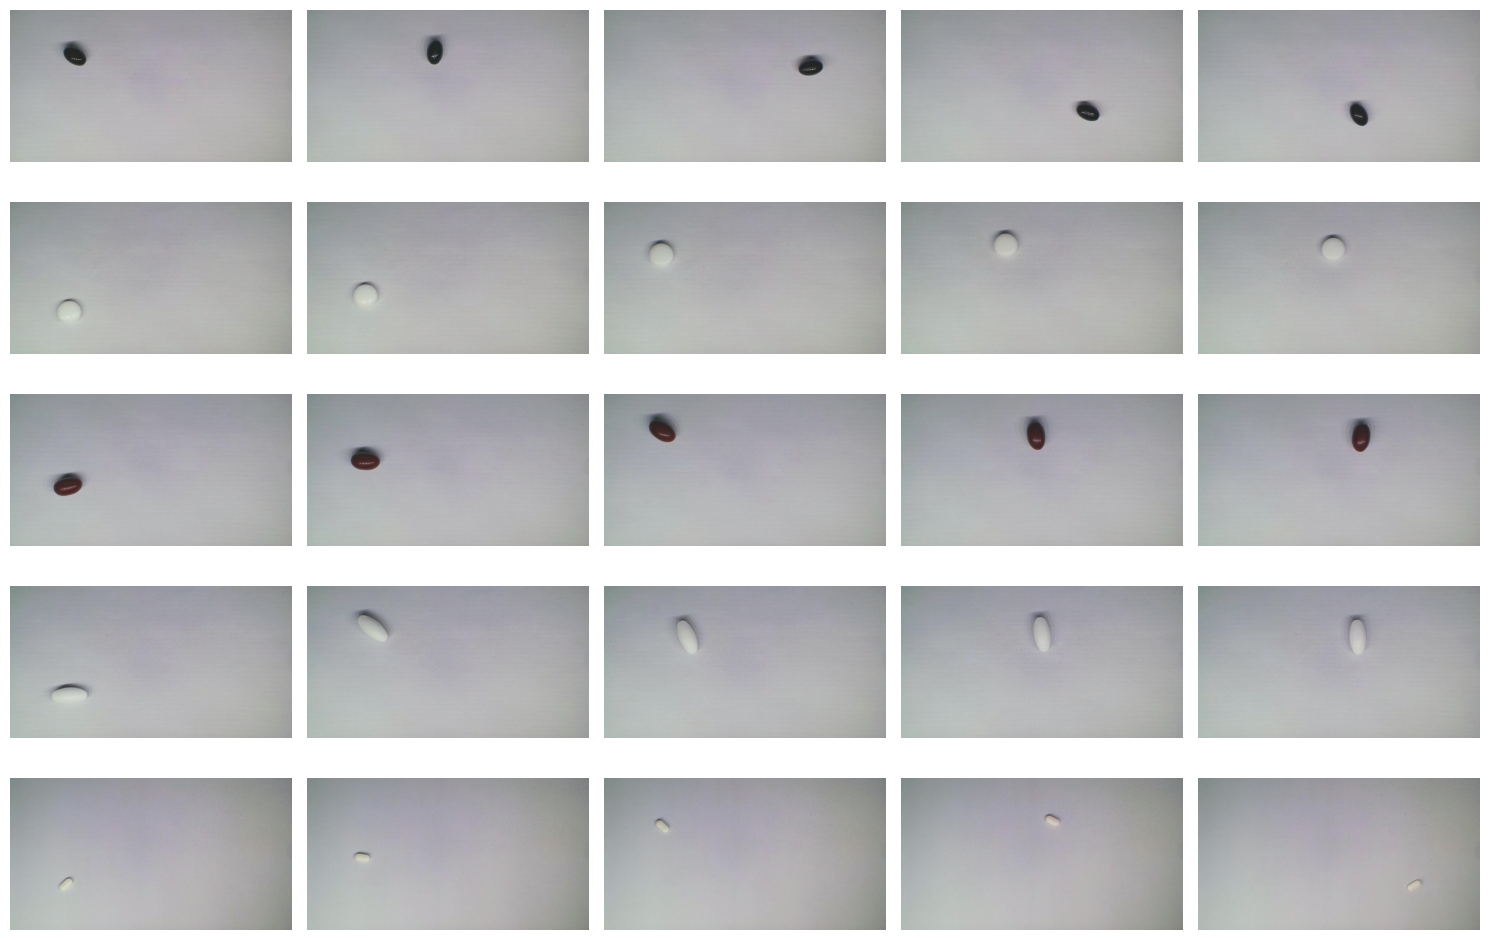

In [ ]:
classes_to_show = ["ocutein", "kalium_r", "novo_c_plus", "kalcium_magnezium_cink", "coverex_4_mg"]

class_indices = {cls: [] for cls in classes_to_show}

for idx, (img, label) in enumerate(dataset):
    cls_name = dataset.classes[label]
    if cls_name in classes_to_show:
        class_indices[cls_name].append(idx)

fig, axes = plt.subplots(len(classes_to_show), 5, figsize=(15, 10))
for row, cls_name in enumerate(classes_to_show):
    indices = class_indices[cls_name][:5]  # первые 5 изображений класса
    for col, idx in enumerate(indices):
        img, _ = dataset[idx]
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls_name, rotation=0, labelpad=50, fontsize=12)

plt.tight_layout()
plt.show()

**Почему модель может ошибаться:**

- схожесть таблеток. Многие таблетки практически одинаковы по форме, размеру и цвету, особенно если изображения небольшие и фон однотонный. Даже человеку иногда бывает сложно различить такие таблетки без дополнительных признаков, например надписей или текстуры.
- ограниченные признаки. ResNet50 обучается на RGB-изображениях, и фактически видит только форму и цвет. Для классов с очень похожими таблетками этих признаков может быть недостаточно, чтобы их различать.
- однотонный фон. На всех изображениях фон примерно одинаковый, что делает признаки таблетки более скудными. Модель фокусируется на форме и тенях, а небольшие различия могут оставаться незамеченными.

In [52]:
from PIL import Image

image = Image.open(r"ogyeiv2\test\coverex_4_mg\coverex_4_mg_s_033.jpg")

input_tensor = val_transform(image).unsqueeze(0)  # добавляем batch dimension

# Предсказание
with torch.no_grad():
    outputs = model(input_tensor)



test_dataset = ImageFolder(ROOT_PATH + "/test")
# Получение класса с наибольшей вероятностью
_, predicted_class = torch.max(outputs, 1)
print(test_dataset.classes[predicted_class.item() ])

cetirizin_10_mg


Как мы видим, модель предсказала неверный класс. Если посмотреть на изображения таблеток предсказанного класса, можно сделать вывод, что таблетки cetirizin_10_mg и coverex_4_mg действительно очень похожи друг на друга.

 ### **Классы, на которых модель не совершает ошибок:**

In [54]:
pills = df[df["f1-score"] == 1]
print(", ".join(pills.index.tolist()))
print(f"Количество классов, на которых модель не совершает ошибок: {len(pills.index.tolist())}")

acc_long_600_mg, advil_ultra_forte, akineton_2_mg, algoflex_forte_dolo_400_mg, algoflex_rapid_400_mg, algopyrin_500_mg, ambroxol_egis_30_mg, apranax_550_mg, aspirin_ultra_500_mg, atoris_20_mg, atorvastatin_teva_20_mg, betaloc_50_mg, bila_git, c_vitamin_teva_500_mg, calci_kid, cataflam_50_mg, cataflam_dolo_25_mg, cold_fx, coldrex, concor_10_mg, concor_5_mg, condrosulf_800_mg, controloc_20_mg, diclopram_75-mg_20-mg, dorithricin_mentol, dulsevia_60_mg, enterol_250_mg, favipiravir_meditop_200_mg, ibumax_400_mg, jutavit_c_vitamin, jutavit_cink, koleszterin_kontroll, lactamed, lactiv_plus, letrox_50_mikrogramm, lordestin_5_mg, merckformin_xr_1000_mg, metothyrin_10_mg, mezym_forte_10_000_egyseg, milgamma, naprosyn_250_mg, narva_sr_1_5_mg_retard, neo_ferro_folgamma_114_mg_0_8_mg, nolpaza_20_mg, normodipine_5_mg, nurofen_forte_400_mg, quamatel_40_mg, rubophen_500_mg, salazopyrin_en_500_mg, sedatif_pc, sicor_10_mg, sinupret_forte, strepfen_8_75_mg, strepsils, teva_ambrobene_30_mg, teva_enteroben

Как мы видим, модель верно предсказывает большинство классов

Давайте взглянем на некоторые изображения классов таблеток, которые модель предсказывает лучше всего:

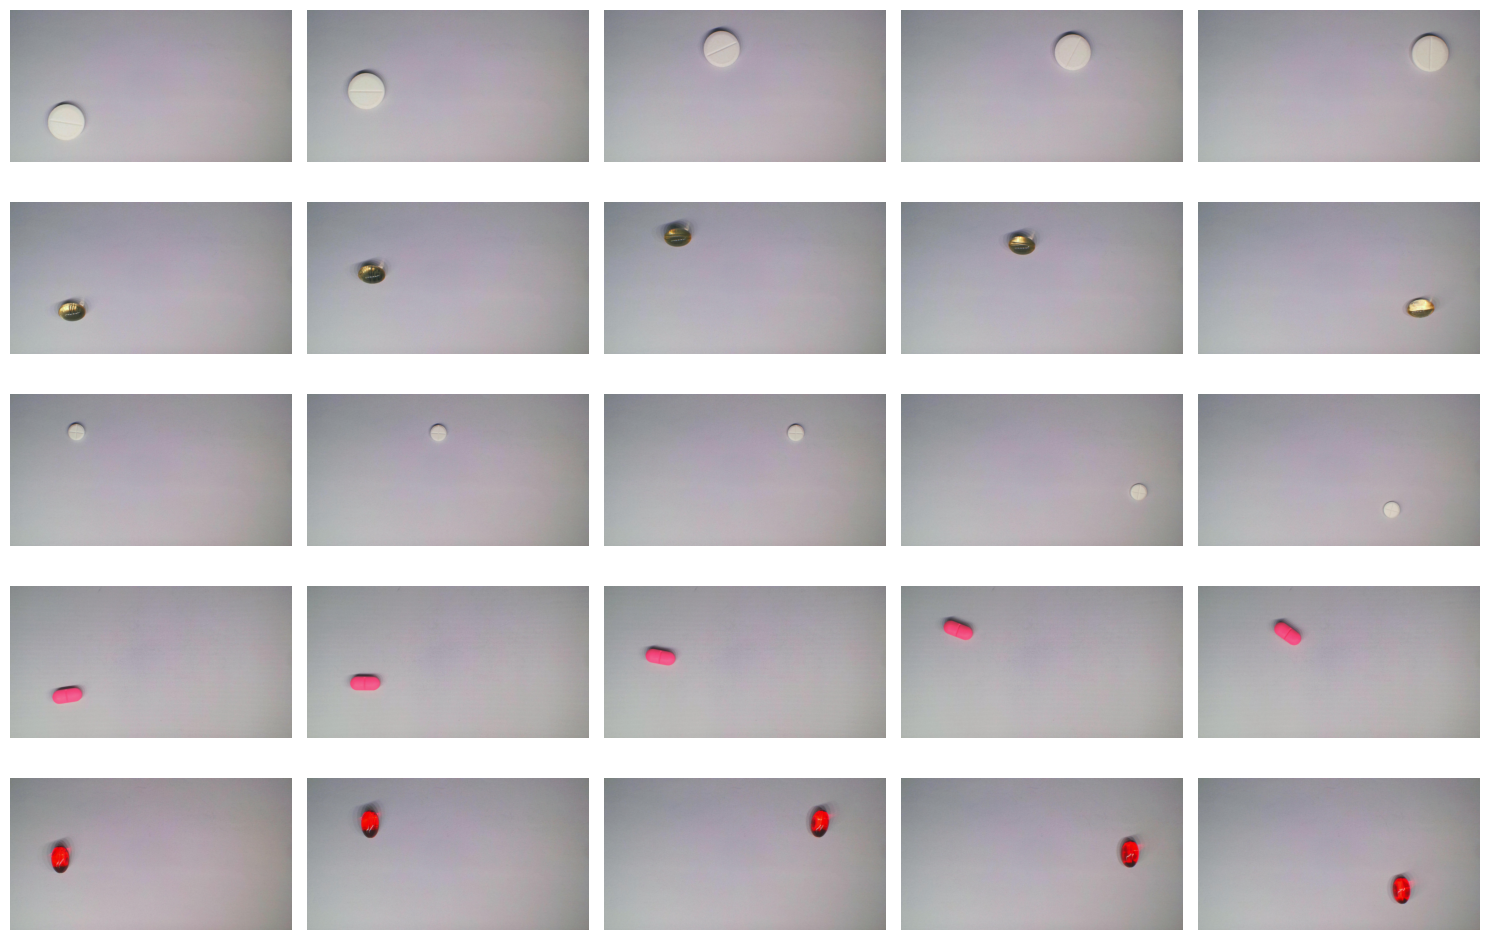

In [55]:
classes_to_show = [
    "acc_long_600_mg",
    "advil_ultra_forte",
    "akineton_2_mg",
    "algoflex_forte_dolo_400_mg",
    "algoflex_rapid_400_mg"
]
class_indices = {cls: [] for cls in classes_to_show}

for idx, (img, label) in enumerate(dataset):
    cls_name = dataset.classes[label]
    if cls_name in classes_to_show:
        class_indices[cls_name].append(idx)

fig, axes = plt.subplots(len(classes_to_show), 5, figsize=(15, 10))
for row, cls_name in enumerate(classes_to_show):
    indices = class_indices[cls_name][:5]  # первые 5 изображений класса
    for col, idx in enumerate(indices):
        img, _ = dataset[idx]
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls_name, rotation=0, labelpad=50, fontsize=12)

plt.tight_layout()
plt.show()

### **Почему эти классы модель распознаёт безошибочно?**

- каждая таблетка отличается по цвету и форме: белые круглые, золотые круглые, белые с риской, розовые капсулы, красные капсулы.
- контуры таблеток легко отделяются от фона.
- расположение и масштаб.  Первое изображение выглядит крупнее по сравнению с фоном, объект занимает почти все изображение. Модель может запомнить этот паттерн: «большая круглая белая таблетка на фоне», что делает распознавание почти тривиальным. 

### **Как можно улучшить точность классификатора?**

Сейчас все данные в датасете - таблетки в одинаковых позициях на белом фоне с одинаковым ракурсом. Модель привыкает к таким условиям и будет намного хуже работать в реальных условиях. Чтобы улучшить точность на реальных фото, нужно: добавить разные фоны (руки, стол, упаковка), менять ракурсы и повороты, разное освещение, масштаб и позиции, иногда класть несколько таблеток вместе, добавить легкий шум, блики и размытие. Только так модель перестанет «зависеть» от идеального фона и будет реально распознавать таблетки в любых условиях.

После этого необходимо будет пересмотреть предобработку датасета. Например: отделять контуры таблетки с помощью фильтров. Применять edge detection или thresholding, можно добавить маски таблеток. Тогда модель будет учиться распознавать форму и границы, а не только цвет и фон, что сильно повышает устойчивость к разным фонам и освещению.

Также, можно пересмотреть аугментацию данных: добавить блики, афинные преобразования

### **Как ещё можно проанализировать результаты и ошибки модели?**



1. Тест на реальных данных - собрать фотографии таблеток в руках, на столе, в упаковке, с разным освещением и ракурсами.
2. Собрать ошибочные примеры и посмотреть закономерности: фон, ракурс, размер, цвет.
3. Визуализация внимания модели (например heatmap) - проверить, на что модель обращает внимание: форму таблетки или фон/блики/масштаб.
4. Сделать тест на изменение контекста - искусственно менять фон, масштаб, поворот или добавлять другие объекты, чтобы увидеть зависимость модели от побочных признаков.